# Banana freshness analysis and compact tree

This notebook uses open banana fresh and spoiled recordings for model training. Open rows are sorted by `Ticks`, divided into recording sessions, and resampled to one median observation per elapsed second. `NO_FRUIT` remains a separate inference state.

The first 20% of both custom fresh and custom spoiled recordings determines a class-anchored affine sensor mapping. The remaining 80% of each recording is held out for custom-domain validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score
from sklearn.model_selection import GroupShuffleSplit
from freshness_tree_model import (
    FEATURES, SENSORS, OPEN_BIN_MS, calibration, even_sample, last_session_split,
    load_open_resampled, load_recording, make_features, make_model, map_custom,
    model_flash_bytes, open_block_groups, open_time_windows, open_training_data,
    predict_quantized, quantize_model,
)

sns.set_theme(style='whitegrid')
X_open, y_open, open_fresh = open_training_data()
open_rotten = load_open_resampled('banana_rotten.csv')
custom_fresh = load_recording('banana_fresh_custom.csv', custom=True)
custom_rotten = load_recording('banana_rotten_custom.csv', custom=True)
custom_spoil = load_recording('banana_starts_to_spoil_custom.csv', custom=True)
no_fruit = load_recording('no_fruit.csv', custom=True)
gain, offset, no_fruit_threshold, fresh_cal_end, rotten_cal_end, no_fruit_cal_end = calibration(
    open_fresh, open_rotten, custom_fresh, custom_rotten, no_fruit
)
custom_fresh_test = custom_fresh.iloc[fresh_cal_end:]
custom_rotten_test = custom_rotten.iloc[rotten_cal_end:]
no_fruit_test = no_fruit.iloc[no_fruit_cal_end:]
features_open = make_features(X_open)
print('Open rows:', len(X_open), 'fresh:', int(y_open.sum()), 'spoiled:', int((1-y_open).sum()))
print('Nine engineered inputs:', list(FEATURES))
print('Open resampling interval:', OPEN_BIN_MS, 'ms')
print('Custom calibration/validation rows: fresh', fresh_cal_end, '/', len(custom_fresh_test),
      'spoiled', rotten_cal_end, '/', len(custom_rotten_test))

Open rows: 733 fresh: 360 spoiled: 373
Nine engineered inputs: ['MQ3_ratio_MQ135', 'MQ3_ratio_MQ5', 'MQ3_minus_MQ5', 'MQ3_minus_MQ135', 'MQ5_ratio_MQ135', 'sensor_std', 'MQ5_minus_MQ135', 'MQ5_plus_MQ135', 'MQ3']
Open resampling interval: 1000 ms
Custom calibration/validation rows: fresh 12049 / 48197 spoiled 1157 / 4630


## Fresh and spoiled domain calibration

For each sensor, the mapping is `open = custom × gain + offset`. Fresh and spoiled calibration medians provide the two anchors. A negative MQ5 gain is required because MQ5 moves in opposite directions between the custom and legacy open domains. The raw MQ3 no-fruit gate is evaluated before this mapping.

,open fresh median,open spoiled median,custom fresh calibration median,custom spoiled calibration median,affine gain,affine offset,held-out mapped fresh median,held-out mapped spoiled median
MQ3,105.0,284.0,89.0,812.85,0.247,82.991,105.705,287.029
MQ5,540.0,1075.0,846.0,93.00,-0.710,1141.076,533.108,1074.787
MQ135,33.0,168.0,68.0,81.15,10.266,-665.099,58.665,163.380


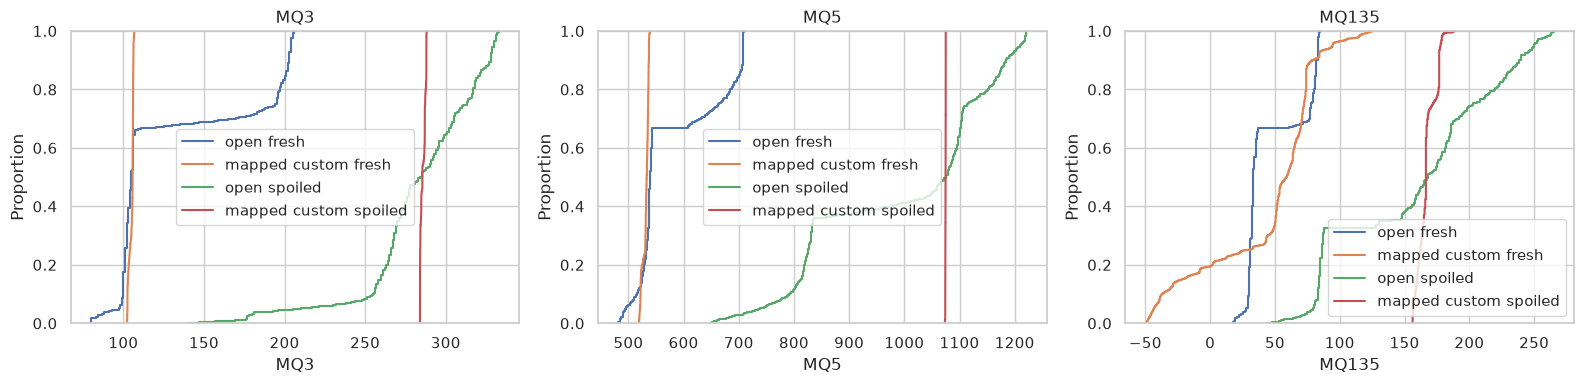

,MQ3,MQ5,MQ135
class,,,
fresh,0.356,0.611,0.404
spoiled,0.500,0.499,0.411


Raw MQ3 no-fruit threshold: 68.375


In [2]:
def mapped(frame):
    return map_custom(frame, gain, offset)

calibration_table = pd.DataFrame({
    'open fresh median': open_fresh.median(),
    'open spoiled median': open_rotten.median(),
    'custom fresh calibration median': custom_fresh.iloc[:fresh_cal_end].median(),
    'custom spoiled calibration median': custom_rotten.iloc[:rotten_cal_end].median(),
    'affine gain': gain,
    'affine offset': offset,
    'held-out mapped fresh median': mapped(custom_fresh_test).median(),
    'held-out mapped spoiled median': mapped(custom_rotten_test).median(),
})
display(calibration_table.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, sensor in zip(axes, SENSORS):
    for label, frame in [('open fresh', open_fresh),
                         ('mapped custom fresh', mapped(custom_fresh_test)),
                         ('open spoiled', open_rotten),
                         ('mapped custom spoiled', mapped(custom_rotten_test))]:
        sns.ecdfplot(even_sample(frame, 3000)[sensor], ax=ax, label=label)
    ax.set_title(sensor); ax.legend()
plt.tight_layout(); plt.show()

ks_rows = []
for label, custom, opened in [('fresh', custom_fresh_test, open_fresh),
                              ('spoiled', custom_rotten_test, open_rotten)]:
    ks_rows.append({'class': label, **{
        sensor: ks_2samp(even_sample(opened, 3000)[sensor],
                         even_sample(mapped(custom), 3000)[sensor]).statistic
        for sensor in SENSORS}})
display(pd.DataFrame(ks_rows).set_index('class').round(3))
print('Raw MQ3 no-fruit threshold:', round(no_fruit_threshold, 3))

## Open-data validation

Balanced accuracy weights fresh and spoiled recall equally. Blocked validation measures local interpolation. Elapsed-time windows and the final-session split expose chronological drift.

In [3]:
groups = open_block_groups(X_open, y_open)
blocked_rows = []
for train_idx, test_idx in GroupShuffleSplit(n_splits=5, test_size=.2, random_state=42).split(
        X_open, y_open, groups):
    model = make_model().fit(features_open.iloc[train_idx], y_open[train_idx])
    predicted = predict_quantized(quantize_model(model), X_open.iloc[test_idx])
    blocked_rows.append({
        'balanced accuracy': balanced_accuracy_score(y_open[test_idx], predicted),
        'macro F1': f1_score(y_open[test_idx], predicted, average='macro'),
        'spoiled recall': recall_score(y_open[test_idx], predicted, pos_label=0),
    })
blocked = pd.DataFrame(blocked_rows)
display(blocked.round(4))
print('Blocked mean/worst balanced accuracy:',
      round(blocked['balanced accuracy'].mean(), 4),
      round(blocked['balanced accuracy'].min(), 4))

window_scores = []
for train_idx, test_idx in open_time_windows(y_open):
    model = make_model().fit(features_open.iloc[train_idx], y_open[train_idx])
    predicted = predict_quantized(quantize_model(model), X_open.iloc[test_idx])
    window_scores.append(balanced_accuracy_score(y_open[test_idx], predicted))
print('Elapsed-time window balanced accuracies:', [round(v, 4) for v in window_scores])

session_train, session_test = last_session_split(X_open, y_open)
session_model = make_model().fit(features_open.iloc[session_train], y_open[session_train])
session_predicted = predict_quantized(quantize_model(session_model), X_open.iloc[session_test])
print('Final-session chronological balanced accuracy:',
      round(balanced_accuracy_score(y_open[session_test], session_predicted), 4))

,balanced accuracy,macro F1,spoiled recall
0,1.0000,1.0000,1.0000
1,1.0000,1.0000,1.0000
2,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000
4,0.9444,0.9327,0.8889


Blocked mean/worst balanced accuracy: 0.9889 0.9444


Elapsed-time window balanced accuracies: [0.8867, 0.9333, 1.0, 1.0, 0.5139]
Final-session chronological balanced accuracy: 0.5084


## Quantized model on held-out custom recordings

The tree is trained only on open data. Custom calibration rows determine the affine mapping and raw no-fruit threshold. Custom validation rows do not fit the tree. `banana_starts_to_spoil_custom.csv` remains diagnostic because it has no forced fresh or spoiled evaluation label.

In [4]:
tree = make_model().fit(features_open, y_open)
nodes = quantize_model(tree)
print('Tree nodes/model bytes:', len(nodes), model_flash_bytes(nodes))
print('Open fitted balanced accuracy (fit check only):',
      round(balanced_accuracy_score(y_open, predict_quantized(nodes, X_open)), 4))

recordings = {
    'held-out custom fresh': (custom_fresh_test, 1),
    'held-out custom spoiled': (custom_rotten_test, 0),
    'held-out no fruit': (no_fruit_test, 2),
    'starts to spoil (diagnostic)': (custom_spoil, None),
}
rows = []
for name, (frame, target) in recordings.items():
    predicted = predict_quantized(nodes, mapped(frame),
                                  no_fruit_threshold=no_fruit_threshold,
                                  raw_values=frame)
    fractions = pd.Series(predicted).value_counts(normalize=True)
    rows.append({
        'recording': name, 'rows': len(frame),
        'known-label accuracy': float(np.mean(predicted == target)) if target is not None else np.nan,
        'predicted NO_FRUIT': fractions.get(2, 0.0),
        'predicted FRESH': fractions.get(1, 0.0),
        'predicted SPOILED': fractions.get(0, 0.0),
    })
results = pd.DataFrame(rows).set_index('recording')
display(results.round(5))
custom_truth = np.r_[np.ones(len(custom_fresh_test), dtype=np.uint8),
                     np.zeros(len(custom_rotten_test), dtype=np.uint8)]
custom_predicted = np.r_[
    predict_quantized(nodes, mapped(custom_fresh_test)),
    predict_quantized(nodes, mapped(custom_rotten_test)),
]
print('Held-out custom fresh/spoiled balanced accuracy:',
      round(balanced_accuracy_score(custom_truth, custom_predicted), 4))

Tree nodes/model bytes: 9 45
Open fitted balanced accuracy (fit check only): 1.0


,rows,known-label accuracy,predicted NO_FRUIT,predicted FRESH,predicted SPOILED
recording,,,,,
held-out custom fresh,48197,0.85016,0.0,0.85016,0.14984
held-out custom spoiled,4630,1.00000,0.0,0.00000,1.00000
held-out no fruit,2485,1.00000,1.0,0.00000,0.00000
starts to spoil (diagnostic),130787,NaN,0.0,0.70093,0.29907


Held-out custom fresh/spoiled balanced accuracy: 0.9251
